<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_initial_2class_phase_2%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load additional preprocessed data files if they exist
with open('../training_data/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../training_data/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('../training_data/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../training_data/y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('../training_data/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../training_data/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_train_labels.shape, np_val_data.shape, np_val_labels.shape, np_test_data.shape, np_test_labels.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


((21908, 30, 3),
 (21908, 2),
 (5477, 30, 3),
 (5477, 2),
 (10903, 30, 3),
 (10903, 2))

In [ ]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).

In [1]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
sys.path.append('../../')
from utils.preprocessing import *



seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/y_test_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/models_data/20251102-141233_simclr_1s_30hz_phase_1.hdf5



working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)
simclr_model = tf.keras.models.load_model("20251102-141233_simclr_1s_30hz_phase_1.hdf5")

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 1184, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 1184 (delta 0), reused 3 (delta 0), pack-reused 1179 (from 2)
Receiving objects: 100% (1184/1184), 281.33 MiB | 16.42 MiB/s, done.
Resolving deltas: 100% (701/701), done.
Updating files: 100% (57/57), done.


/content/Bachelorarbeit/notebooks/training/transformations.py:35: SyntaxWarning: invalid escape sequence '\&'
  @inproceedings{TerryUm_ICMI2017, author = {Um, Terry T. and Pfister, Franz M. J. and Pichler, Daniel and Endo, Satoshi and Lang, Muriel and Hirche, Sandra and Fietzek, Urban and Kuli\'{c}, Dana}, title = {Data Augmentation of Wearable Sensor Data for Parkinson's Disease Monitoring Using Convolutional Neural Networks}, booktitle = {Proceedings of the 19th ACM International Conference on Multimodal Interaction}, series = {ICMI 2017}, year = {2017}, isbn = {978-1-4503-5543-8}, location = {Glasgow, UK}, pages = {216--220}, numpages = {5}, doi = {10.1145/3136755.3136817}, acmid = {3136817}, publisher = {ACM}, address = {New York, NY, USA}, keywords = {Parkinson\&#39;s disease, convolutional neural networks, data augmentation, health monitoring, motor state detection, wearable sensor}, }


--2025-11-14 09:42:04--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15773925 (15M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]  15.04M  --.-KB/s    in 0.04s   

2025-11-14 09:42:05 (395 MB/s) - ‘X_train_normalized.pkl’ saved [15773925/15773925]

--2025-11-14 09:42:05--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:

## 1.1 Pretraining with SimCLR

In [ ]:
# Parameters for all experiments
window_size = 30
input_shape = (window_size, 3)
batch_size = 512
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 200
temperature = 0.1


In [ ]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x7c37a8aa4400>
1 <function channel_shuffle_transform_vectorized at 0x7c37a8aa4360>


In [ ]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model_small_dimensions(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 12.834
epoch: 2 loss: 10.802
epoch: 3 loss: 10.818
epoch: 4 loss: 10.589
epoch: 5 loss: 11.020
epoch: 6 loss: 10.394
epoch: 7 loss: 10.002
epoch: 8 loss: 9.353
epoch: 9 loss: 8.867
epoch: 10 loss: 9.484
epoch: 11 loss: 9.213
epoch: 12 loss: 9.196
epoch: 13 loss: 8.558
epoch: 14 loss: 8.974
epoch: 15 loss: 8.636
epoch: 16 loss: 8.142
epoch: 17 loss: 8.172
epoch: 18 loss: 8.316
epoch: 19 loss: 8.161
epoch: 20 loss: 8.011
epoch: 21 loss: 8.333
epoch: 22 loss: 7.481
epoch: 23 loss: 7.749
epoch: 24 loss: 7.381
epoch: 25 loss: 7.706
epoch: 26 loss: 7.439
epoch: 27 loss: 7.443
epoch: 28 loss: 7.826
epoch: 29 loss: 8.715
epoch: 30 loss: 7.818
epoch: 31 loss: 6.727
epoch: 32 loss: 7.374
epoch: 33 loss: 7.025
epoch: 34 loss: 6.925
epoch: 35 loss: 6.811
epoch: 36 loss: 6.939
epoch: 37 loss: 6.483
epoch: 38 loss: 6.435
epoch: 39 loss: 6.784
epoch: 40 loss: 6.411
epoch: 41 loss: 6.387
epoch: 42 loss: 6.378
epoch: 43 loss: 6.600
epoch: 44 loss: 6.076
epoch: 45 loss: 6.218
epoch: 46 lo

epoch: 200 loss: 2.560


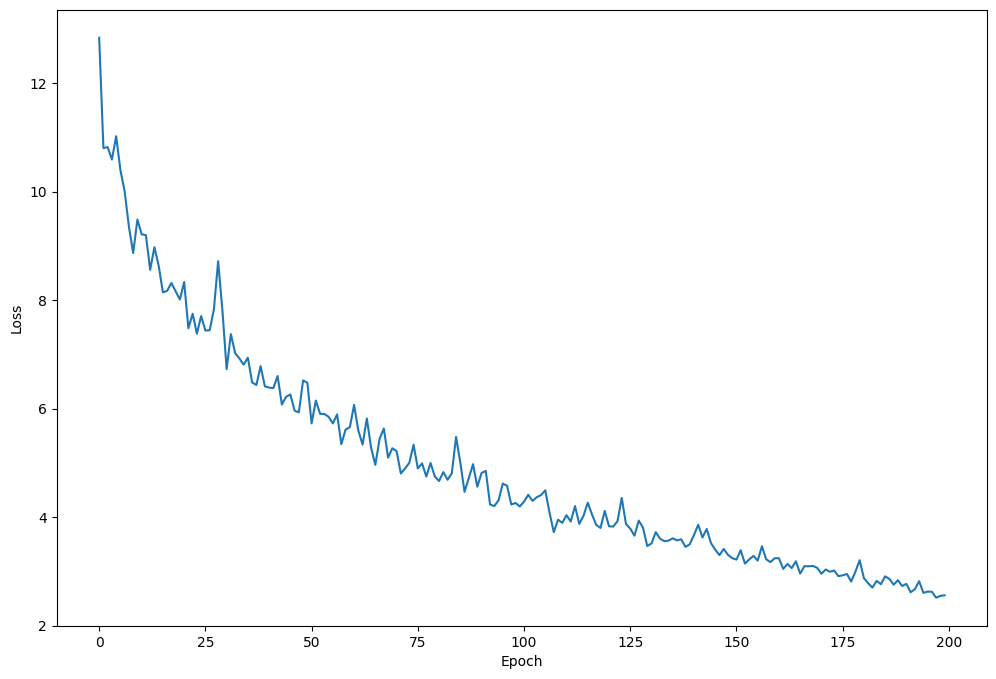

In [ ]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [ ]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 673ms/step - auc: 0.7709 - categorical_accuracy: 0.7231 - loss: 0.5673 - precision: 0.7231 - recall: 0.7231 - val_auc: 0.9530 - val_categorical_accuracy: 0.9006 - val_loss: 0.3713 - val_precision: 0.9006 - val_recall: 0.9006
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.9327 - categorical_accuracy: 0.8790 - loss: 0.3837 - precision: 0.8790 - recall: 0.8790 - val_auc: 0.9576 - val_categorical_accuracy: 0.9034 - val_loss: 0.3230 - val_precision: 0.9034 - val_recall: 0.9034
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.9372 - categorical_accuracy: 0.8821 - loss: 0.3518 - precision: 0.8821 - recall: 0.8821 - val_auc: 0.9599 - val_categorical_accuracy: 0.9006 - val_loss: 0.2996 - val_precision: 0.9006 - val_recall: 0.9006
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.9410 - categorical_accuracy: 0.8845 - loss: 0.3358 - precision: 0.8845 - recall: 0.8845 - val_auc: 0.9614 - val_categorical_accuracy: 0.9006 - val_loss

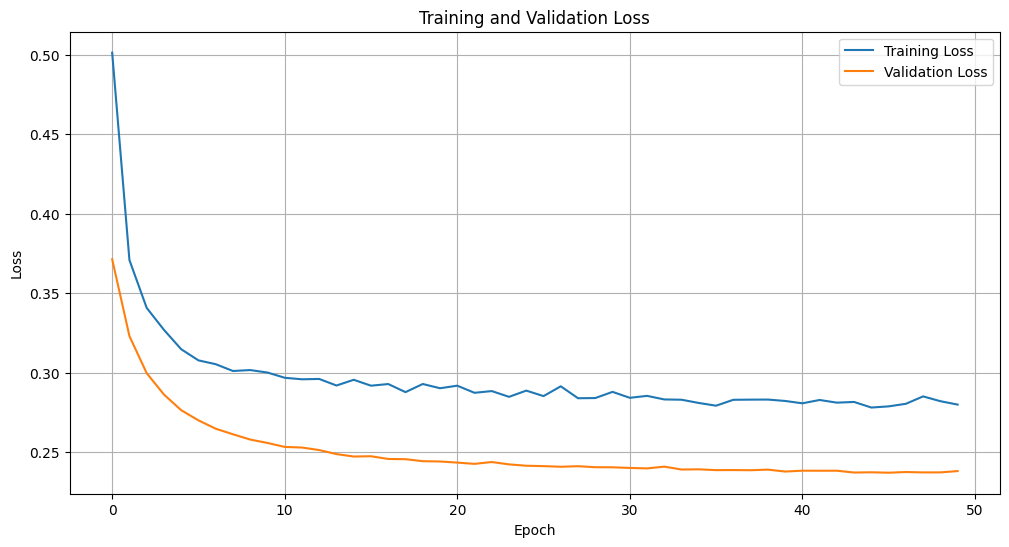

In [ ]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

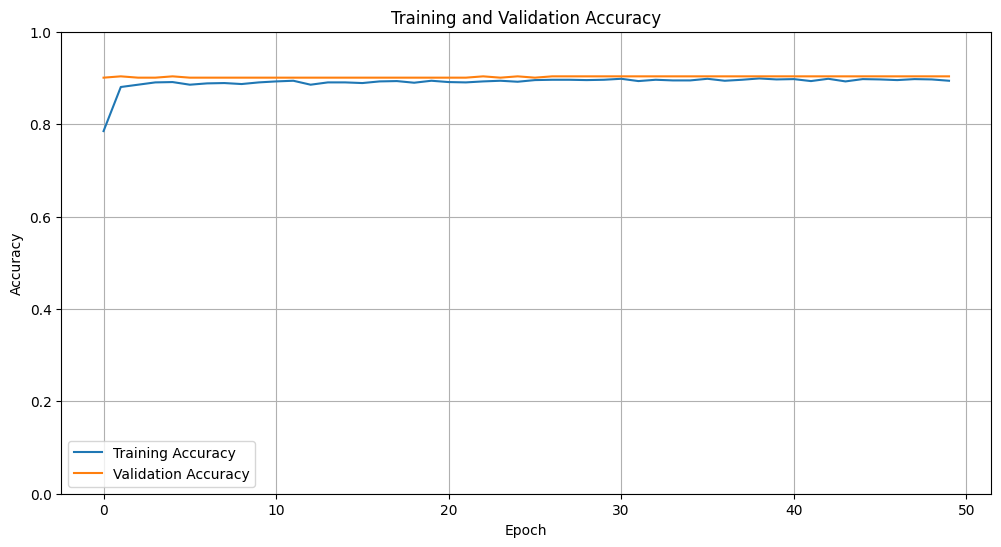

In [ ]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

### 1.2.2 Full HAR Model

#### Train

In [ ]:
total_epochs = 50
batch_size = 200
tag = "full_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

simclr_model = tf.keras.models.load_model("../models/20251102-141233_simclr_1s_30hz_phase_1.hdf5")
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - auc: 0.9794 - categorical_accuracy: 0.9474 - loss: 0.1697 - precision: 0.9474 - recall: 0.9474 - val_auc: 0.9956 - val_categorical_accuracy: 0.9704 - val_loss: 0.0891 - val_precision: 0.9704 - val_recall: 0.9704
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - auc: 0.9956 - categorical_accuracy: 0.9733 - loss: 0.0842 - precision: 0.9733 - recall: 0.9733 - val_auc: 0.9962 - val_categorical_accuracy: 0.9750 - val_loss: 0.0844 - val_precision: 0.9750 - val_recall: 0.9750
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - auc: 0.9961 - categorical_accuracy: 0.9757 - loss: 0.0786 - precision: 0.9757 - recall: 0.9757 - val_auc: 0.9968 - val_categorical_accuracy: 0.9775 - val_loss: 0.0801 - val_precision: 0.9775 - val_recall: 0.9775
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - auc: 0.9963 - categorical_accuracy: 0.9782 - loss: 0.0724 - precision: 0.9782 - recall: 0.9782 - val_auc: 0.9973 - val_categorical_accuracy: 0.9823 - val_l

KeyboardInterrupt: 

#### Plot metrics

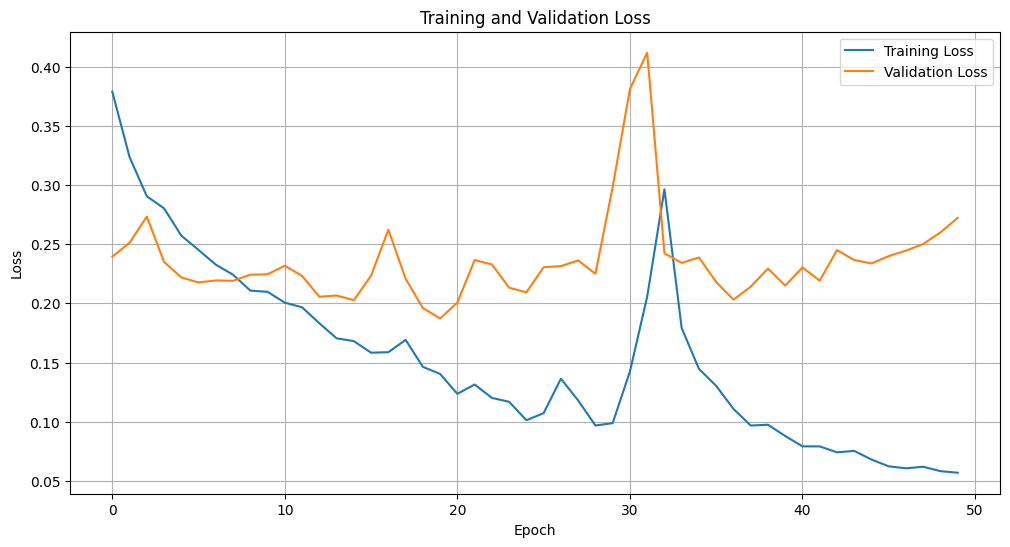

In [ ]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

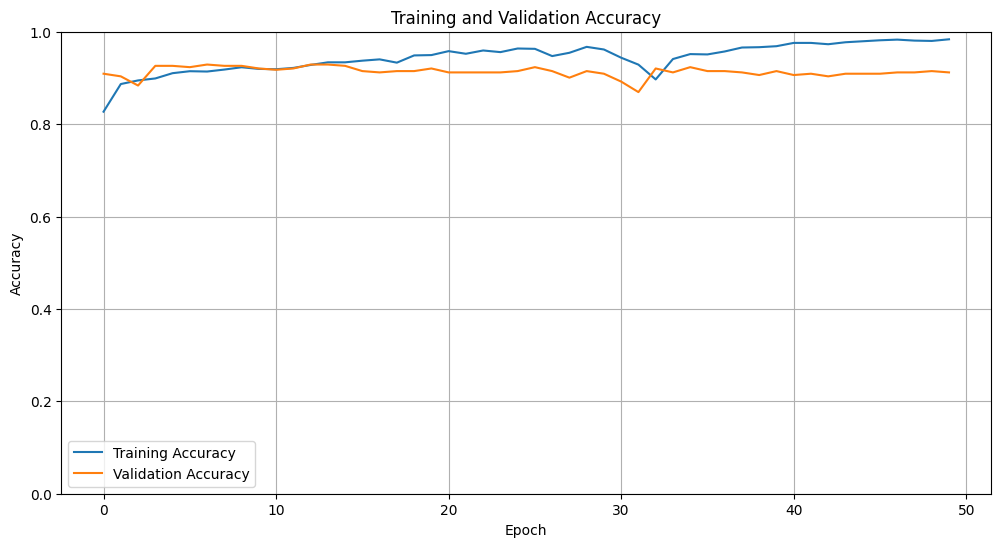

In [ ]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

# Evaluation of real-world test data

In [ ]:
# load data
with open('../training_data/X_test_normalized.pkl', 'rb') as f:
    np_test_data_real_world = pickle.load(f)
with open('../training_data/y_test_onehot.pkl', 'rb') as f:
    np_test_labels_real_world = pickle.load(f)


In [ ]:
full_eval_best_model_file_name = "../models/20251102-141233_simclr_full_eval_1s_30hz_realworld.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)


print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(np_test_data_real_world), np_test_labels_real_world, return_dict=True))

 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
{'Confusion Matrix': array([[211,  36],
       [ 50, 197]]), 'F1 Macro': 0.825770997375328, 'F1 Micro': 0.8259109311740891, 'F1 Weighted': 0.8257709973753281, 'Precision': 0.8269613405028531, 'Recall': 0.8259109311740891, 'Kappa': np.float64(0.6518218623481782)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


In [ ]:
# save the predicted labels in a pickle file
predicted_labels = full_eval_best_model.predict(np_test_data_real_world)
with open('../training_data/y_test_predicted_labels.pkl', 'wb') as f:
    pickle.dump(predicted_labels, f)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


## t-SNE Plots

In [ ]:
import sklearn.manifold
import seaborn as sns

In [ ]:

perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(full_eval_best_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(np_test_data_real_world, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "TPN_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 49,248 (192.38 KB)

 Non-trainable params: 35,168 (137.38 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(494, 30, 3))
  warnings.warn(msg)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 494 samples in 0.001s...
[t-SNE] Computed neighbors for 494 samples in 0.283s...
[t-SNE] Computed conditional probabilities for sample 494 / 494
[t-SNE] Mean sigma: 4.267158
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.534985
[t-SNE] KL divergence after 1000 iterations: 0.444002


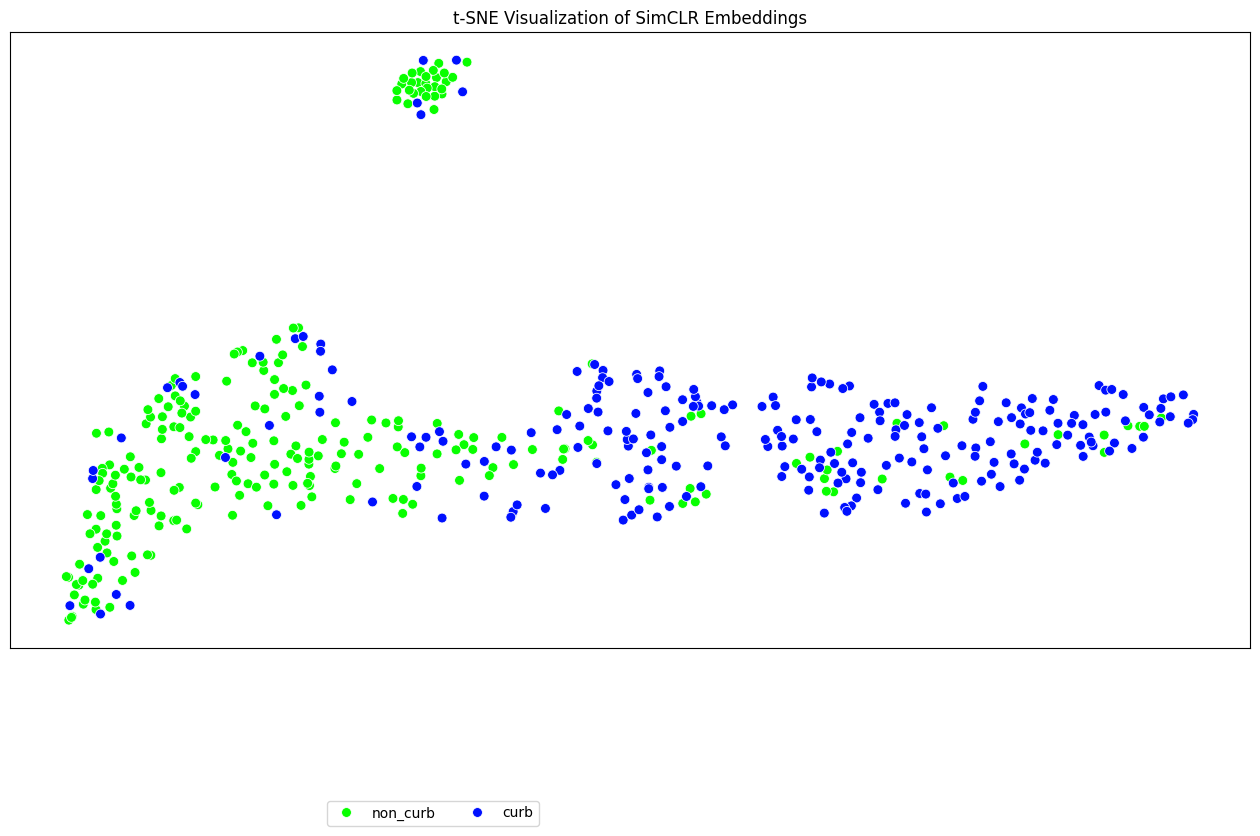

In [ ]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels_real_world, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["non_curb", "curb"]  # Replace with your actual class names

# Update legend with class names if available
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():  # Check if variable exists
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)